# Advantage Actor-Critic (A2C) Agent

Actor-Critic architectures combine policy networks (Actor) and value estimation networks (Critic). Critic estimates value boundaries, while Actor calculates policy gradients relative to Critic baseline predictions (Advantage). This notebook implements an Advantage Actor-Critic (A2C) agent in PyTorch to balance a cartpole in a physical simulator.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import numpy as np
import matplotlib.pyplot as plt

# Custom Physics Simulator for CartPole (Simplified State Dimensions)
class SimpleCartPole:
    def __init__(self):
        self.reset()
        
    def reset(self):
        self.state = np.array([0.0, 0.0, 0.05 * np.random.uniform(-1, 1), 0.0], dtype=np.float32)
        self.steps = 0
        return self.state
        
    def step(self, action):
        self.steps += 1
        x, x_dot, theta, theta_dot = self.state
        
        force = 10.0 if action == 1 else -10.0
        g = 9.8
        m_c = 1.0
        m_p = 0.1
        length = 0.5
        
        temp = (force + m_p * length * theta_dot**2 * np.sin(theta)) / (m_c + m_p)
        theta_acc = (g * np.sin(theta) - np.cos(theta) * temp) / (length * (4.0/3.0 - m_p * np.cos(theta)**2 / (m_c + m_p)))
        x_acc = temp - m_p * length * theta_acc * np.cos(theta) / (m_c + m_p)
        
        dt = 0.02
        x += dt * x_dot
        x_dot += dt * x_acc
        theta += dt * theta_dot
        theta_dot += dt * theta_acc
        
        self.state = np.array([x, x_dot, theta, theta_dot], dtype=np.float32)
        
        done = False
        if abs(x) > 2.4 or abs(theta) > 0.209 or self.steps >= 200:
            done = True
            
        reward = 1.0
        return self.state, reward, done

env = SimpleCartPole()



## A2C Actor-Critic Network Architecture

We build our Actor-Critic network in PyTorch. It contains a shared input layer and splits into:
1. **Actor Head**: Computes categorical action probabilities.
2. **Critic Head**: Computes a scalar coordinate estimating expected future rewards ($V(s)$).



In [2]:
class ActorCritic(nn.Module):
    def __init__(self, state_dim=4, action_dim=2):
        super(ActorCritic, self).__init__()
        
        self.shared = nn.Sequential(
            nn.Linear(state_dim, 32),
            nn.ReLU()
        )
        
        self.actor = nn.Sequential(
            nn.Linear(32, action_dim),
            nn.Softmax(dim=-1)
        )
        
        self.critic = nn.Linear(32, 1)
        
    def forward(self, x):
        h = self.shared(x)
        return self.actor(h), self.critic(h)

model = ActorCritic(state_dim=4, action_dim=2)
optimizer = optim.Adam(model.parameters(), lr=0.01)



## A2C Convergence Training Loop

We train our agent for 200 episodes. After each step, we calculate Temporal Difference (TD) target, compute Critic value loss and Actor advantage values, and update networks:
$$\text{Advantage} = r + \gamma V(s') - V(s)$$
$$\text{Loss} = \text{CriticLoss} - \log \pi(a|s) \cdot \text{Advantage}$$



In [3]:
epochs = 200
gamma = 0.99
episode_rewards = []

print("Training Advantage Actor-Critic (A2C) agent...")
for ep in range(1, epochs + 1):
    state = env.reset()
    done = False
    total_reward = 0
    
    while not done:
        state_t = torch.FloatTensor(state)
        probs, value = model(state_t)
        
        m = Categorical(probs)
        action = m.sample()
        
        next_state, reward, done = env.step(action.item())
        total_reward += reward
        
        # Calculate Critic prediction for next state
        next_state_t = torch.FloatTensor(next_state)
        _, next_value = model(next_state_t)
        
        # Compute TD Target & Advantage
        td_target = reward + (0.0 if done else gamma * next_value.item())
        advantage = td_target - value.item()
        
        # Critic MSE loss
        critic_loss = (value - td_target).pow(2)
        
        # Actor advantage loss
        actor_loss = -m.log_prob(action) * advantage
        
        # Joint gradient update
        loss = actor_loss + 0.5 * critic_loss
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        state = next_state
        
    episode_rewards.append(total_reward)
    
    if ep % 40 == 0:
        avg_reward = np.mean(episode_rewards[-40:])
        print(f"Episode {ep:3d}/{epochs} | Average Reward (last 40): {avg_reward:.2f}")



Training Advantage Actor-Critic (A2C) agent...
Episode  40/200 | Average Reward (last 40): 10.00
Episode  80/200 | Average Reward (last 40): 9.28
Episode 120/200 | Average Reward (last 40): 9.68
Episode 160/200 | Average Reward (last 40): 9.60
Episode 200/200 | Average Reward (last 40): 9.47


## Reward Convergence Plot

We plot cumulative episode steps balanced across training runs using Matplotlib.



<cell>:13: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



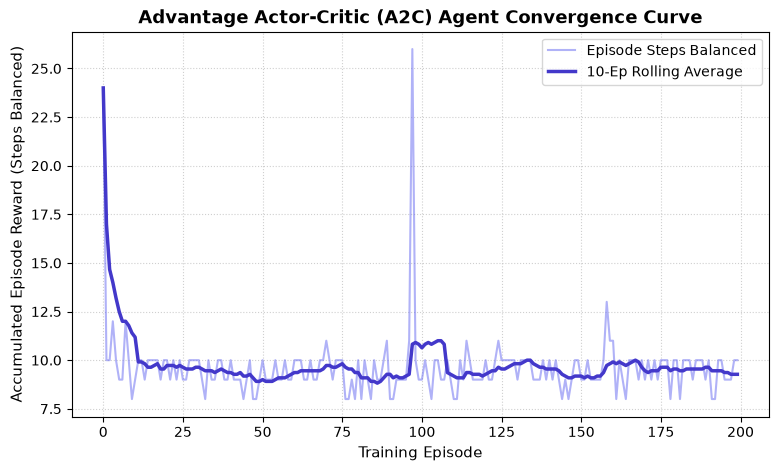

In [4]:
plt.figure(figsize=(9, 5))
plt.plot(episode_rewards, label='Episode Steps Balanced', color='#6366F1', alpha=0.5)

# Rolling average overlay
rolling_rewards = [np.mean(episode_rewards[max(0, i-10):i+1]) for i in range(len(episode_rewards))]
plt.plot(rolling_rewards, label='10-Ep Rolling Average', color='#4338CA', linewidth=2.5)

plt.title('Advantage Actor-Critic (A2C) Agent Convergence Curve', fontsize=13, fontweight='bold')
plt.xlabel('Training Episode', fontsize=11)
plt.ylabel('Accumulated Episode Reward (Steps Balanced)', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
